In [1]:
import warnings
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import blpapi
import numpy as np

# 忽略 Seaborn/Pandas 产生的 CategoricalDtype 弃用警告
warnings.filterwarnings('ignore', category=FutureWarning, module='seaborn')
warnings.filterwarnings('ignore', message='.*is_categorical_dtype.*')

# 设置绘图风格与中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid", font='SimHei')

In [2]:
# ==========================================
# 0. 过滤国内交易所合约 (如 pd2606.GFE, zn2507.SHFE)
# ==========================================
def filter_onshore_contracts(df, ticker_col='标的全称'):
    """
    过滤掉标的全称为国内交易所格式的合约 (.GFE, .SHFE, .DCE, .CZCE, .CFFEX, .INE)
    """
    pattern = r'\.(?:GFE|SHFE|DCE|CZCE|CFFEX|INE)$'
    mask = df[ticker_col].astype(str).str.contains(pattern, case=False, na=False)
    filtered_df = df[~mask].copy()
    print(f"过滤国内交易所合约完成：共移除 {mask.sum()} 条数据，剩余 {len(filtered_df)} 条数据。")
    return filtered_df

In [3]:
# ==========================================
# 1. 剔除交易所后缀的清洗函数
# ==========================================
def clean_ticker(ticker):
    if pd.isna(ticker):
        return ticker
    return re.sub(r'\.[A-Za-z0-9]+$', '', str(ticker).strip())

In [4]:
def convert_to_generic_ticker(ticker):
    """
    将具体的期货/期权/LME合约 Ticker 转换为彭博通用主连 Ticker (Generic Ticker)
    
    规则示例：
      1. LME 合约（如 LMZSDP 20261216 Comdty / LMZSDP Comdty） -> 'LMZSDY Comdty'
      2. 外汇/现货标的（如 XPTUSD Curncy）                      -> 'XPTUSD Curncy' (保持原样)
      3. 带空格的农产品合约（如 W Z6 Comdty, C Z6 Comdty）      -> 'W 1 Comdty', 'C 1 Comdty'
      4. 中国金融期货（如 IF2609 Index）                        -> 'IF1 Index'
      5. 无空格标准期货（如 CLZ6 Comdty）                        -> 'CL1 Comdty'
    """
    if not ticker or not isinstance(ticker, str):
        return ticker

    ticker = ticker.strip()
    # 带日期的贵金属合约使用现货代码查询，避免生成 XPTUSD1。
    precious_pair = re.match(r'^(XPT|XPD|XAU|XAG)(USD|CNH)(?=\s|$)', ticker, re.IGNORECASE)
    if precious_pair:
        return f"{precious_pair.group(0).upper()} Curncy"

    
    # 匹配彭博 Yellow Key (Comdty, Curncy, Index, Govt, Corp 等)
    yk_match = re.search(r'\b(Comdty|Curncy|Index|Govt|Corp)\b', ticker, re.IGNORECASE)
    if not yk_match:
        return ticker

    yellow_key = yk_match.group(1)
    prefix = ticker[:yk_match.start()].strip()

    # 外汇/贵金属现货标的（如 XPTUSD Curncy, EURUSD Curncy）保持原代码不变
    if yellow_key.lower() == 'curncy' and not re.search(r'[FGHJKMNQUVXZ]\d|\d{3,4}', prefix, re.IGNORECASE):
        return ticker

    # 规则 1：处理 LME 格式代码（支持带年月日如 LMZSDP 20261216 或不带日期的 LMZSDP）
    lme_match = re.match(r'^(LM[A-Z]{3})[A-Z0-9]*', prefix, re.IGNORECASE)
    if lme_match:
        base = lme_match.group(1)
        # 截取前 5 位（如 LMZSD）并统一替换最后一个字母为 Y -> LMZSDY
        return f"{base[:5]}Y {yellow_key}"

    # 规则 2：处理带空格的品种代码（如 W Z6, C Z6 -> W 1, C 1）
    space_code_match = re.match(r'^([A-Za-z]+)\s+[FGHJKMNQUVXZ]\d', prefix, re.IGNORECASE)
    if space_code_match:
        return f"{space_code_match.group(1)} 1 {yellow_key}"

    # 规则 3：匹配数字年月格式（如 IF2609 -> IF1 Index）
    m_num = re.match(r'^([A-Za-z]+)\d{3,4}', prefix)
    if m_num:
        return f"{m_num.group(1)}1 {yellow_key}"

    # 规则 4：匹配标准无空格合约格式（如 CLZ6 -> CL1 Comdty）
    m_month = re.match(r'^([A-Za-z]+?)[FGHJKMNQUVXZ]\d', prefix, re.IGNORECASE)
    if m_month:
        return f"{m_month.group(1)}1 {yellow_key}"

    # 规则 5：兜底提取开头的字母
    m_root = re.match(r'^([A-Za-z]+)', prefix)
    if m_root:
        return f"{m_root.group(1)}1 {yellow_key}"

    return ticker

In [5]:
# ==========================================
# 3. 彭博数据调取函数（含计价币种与 USD 汇率转换）
# ==========================================

def _positive_number(value):
    """缺失或无效数字保留为 None，只有有限正数可用。"""
    try:
        number = float(value)
    except (TypeError, ValueError):
        return None
    return number if np.isfinite(number) and number > 0 else None


def _read_bbg_field(fields, name, numeric=False):
    """保留彭博缺失和 null，不提前填入业务默认值。"""
    if not fields.hasElement(name) or fields.getElement(name).isNull():
        return None
    if numeric:
        return _positive_number(fields.getElementAsFloat(name))
    return fields.getElementAsString(name).strip() or None


def _precious_metal_override(ticker):
    """贵金属合约的业务规则，不依赖彭博是否返回数据。"""
    if not isinstance(ticker, str):
        return {}
    code = ticker.strip().upper()
    if not code.startswith(('XPT', 'XPD', 'XAU', 'XAG')):
        return {}
    info = {"Contract_Size": 1.0, "Category": "Precious Metal"}
    pair = re.match(r'^(XPT|XPD|XAU|XAG)(USD|CNH)(?=\s|$)', code)
    if pair:
        info["Currency"] = pair.group(2)
    return info


def _contract_override(ticker):
    """显式业务规则优先于彭博数据；仅覆盖指定合约，不扩展到其他月份。"""
    info = _precious_metal_override(ticker)
    if not isinstance(ticker, str):
        return info
    code = " ".join(ticker.upper().split())
    if not code:
        return info
    if code == "HIK5 INDEX":
        info["Currency"] = "HKD"
    currency_by_contract = {"BOK5": "USD", "ADM5": "AUD", "ECM5": "EUR"}
    currency = currency_by_contract.get(code.split()[0])
    if currency:
        info["Currency"] = currency
    if code.endswith("NDF"):
        info.update({"Contract_Size": 1.0, "Currency": "USD"})
    return info


def get_bloomberg_data(tickers):
    """
    通过 Bloomberg API 调取合约乘数、分类字段以及合约计价币种，
    并自动调取非 USD 币种兑 USD 的即期汇率，实现美元统一计价。
    """
    ticker_map = {t: convert_to_generic_ticker(t) for t in tickers}
    generic_tickers = list(set(ticker_map.values()))

    # 增加 "CRNCY" 字段以获取合约的计价币种
    fields = ["FUT_CONT_SIZE", "FUTURES_CATEGORY", "MARKET_SECTOR_DES", "COMMODITY_GROUP", "CRNCY"]

    sessionOptions = blpapi.SessionOptions()
    sessionOptions.setServerHost("localhost")
    sessionOptions.setServerPort(8194)
    session = blpapi.Session(sessionOptions)

    if not session.start() or not session.openService("//blp/refdata"):
        raise ConnectionError("无法连接到 Bloomberg API Session，请确保彭博终端已启动。")

    refDataService = session.getService("//blp/refdata")

    # ----------------------------------------------------
    # 第一步：调取合约基本信息 (Multiplier, Category, Currency)
    # ----------------------------------------------------
    request = refDataService.createRequest("ReferenceDataRequest")
    all_tickers_to_query = list(set(list(tickers) + generic_tickers))
    for t in all_tickers_to_query:
        request.append("securities", t)

    for f in fields:
        request.append("fields", f)

    session.sendRequest(request)

    raw_bbg_data = {}
    # 即使彭博返回 securityError，也要请求业务规则指定的非美元汇率。
    overrides = {t: _contract_override(t) for t in tickers}
    currencies_needed = {
        info["Currency"] for info in overrides.values()
        if info.get("Currency") and info["Currency"] != "USD"
    }

    while True:
        event = session.nextEvent(500)
        if event.eventType() in [blpapi.Event.RESPONSE, blpapi.Event.PARTIAL_RESPONSE]:
            for msg in event:
                if msg.hasElement("securityData"):
                    sec_array = msg.getElement("securityData")
                    for i in range(sec_array.numValues()):
                        sec_data = sec_array.getValueAsElement(i)
                        security = sec_data.getElementAsString("security")
                        if sec_data.hasElement("securityError") or not sec_data.hasElement("fieldData"):
                            continue
                        field_data = sec_data.getElement("fieldData")

                        cont_size = _read_bbg_field(field_data, "FUT_CONT_SIZE", numeric=True)
                        fut_cat = field_data.getElementAsString("FUTURES_CATEGORY") if field_data.hasElement("FUTURES_CATEGORY") else ""
                        mkt_sector = field_data.getElementAsString("MARKET_SECTOR_DES") if field_data.hasElement("MARKET_SECTOR_DES") else ""
                        # comdty_grp = field_data.getElementAsString("COMMODITY_GROUP") if field_data.hasElement("COMMODITY_GROUP") else ""
                        currency = _read_bbg_field(field_data, "CRNCY")

                        category = fut_cat or mkt_sector or "Unclassified"
                        
                        # 针对外汇/现货贵金属标的（如 XPTUSD Curncy / XAUUSD Curncy）的规则优化
                        if security.startswith("XPT") or security.startswith("XAU") or security.startswith("XAG") or security.startswith("XPD"):
                            category = "Precious Metal"
                            
                        # 保留大小写；GBp 等子单位不能静默转为 GBP，需要明确换算规则。

                        if currency and currency != "USD" and re.fullmatch(r"[A-Z]{3}", currency):
                            currencies_needed.add(currency)

                        raw_bbg_data[security] = {
                            "Contract_Size": cont_size,
                            "FUTURES_CATEGORY": category,
                            "Currency": currency
                        }

        if event.eventType() == blpapi.Event.RESPONSE:
            break

    # ----------------------------------------------------
    # 第二步：调取外汇即期汇率 (转换为折算美元系数)
    # ----------------------------------------------------
    fx_rates = {"USD": 1.0}

    if currencies_needed:
        fx_request = refDataService.createRequest("ReferenceDataRequest")
        fx_ticker_map = {}

        for ccy in currencies_needed:
            # 尝试直接调取 CCYUSD Curncy (如 EURUSD Curncy, GBPUSD Curncy)
            fx_ticker = f"{ccy}USD Curncy"
            fx_ticker_map[fx_ticker] = ccy
            fx_request.append("securities", fx_ticker)

        fx_request.append("fields", "PX_LAST")
        session.sendRequest(fx_request)

        while True:
            event = session.nextEvent(500)
            if event.eventType() in [blpapi.Event.RESPONSE, blpapi.Event.PARTIAL_RESPONSE]:
                for msg in event:
                    if msg.hasElement("securityData"):
                        sec_array = msg.getElement("securityData")
                        for i in range(sec_array.numValues()):
                            sec_data = sec_array.getValueAsElement(i)
                            sec_name = sec_data.getElementAsString("security")
                            if sec_data.hasElement("securityError") or not sec_data.hasElement("fieldData"):
                                continue
                            field_data = sec_data.getElement("fieldData")
                            ccy = fx_ticker_map.get(sec_name)
                            rate = _read_bbg_field(field_data, "PX_LAST", numeric=True)
                            if ccy and rate is not None:
                                fx_rates[ccy] = rate

            if event.eventType() == blpapi.Event.RESPONSE:
                break

    session.stop()

    # 第三步：分类归集与特判修正逻辑
    # 1) 特定品种的硬编码特判修正 (覆盖彭博 Fibers 归类误判)
    TICKER_OVERRIDE = {
        'CT': 'Agriculture',    # 美棉 Cotton 修正为 Agriculture
        'PFR': 'Chemicals',         # 对二甲苯 Paraxylene 修正为 Energy (化工/能源链)
        'ZZB': 'Chemicals',
        'SCO': 'Ferrous',
        'MFS': 'Ferrous',
        'SWB': 'Currency',
        'USDCNY': 'Currency'
    }

    CATEGORY_MAPPING = {
        # 能源类 (Energy)
        'Petroleum': 'Energy',
        'Crude Oil': 'Energy',
        'Refined Products': 'Energy',
        'Natural Gas': 'Energy',
        'Energy': 'Energy',
        
        # 农业与农产品 (Agriculture)
        'Other Grain': 'Agriculture',
        'Foodstuff': 'Agriculture',
        'Soy': 'Agriculture',
        'Wheat': 'Agriculture',
        'Corn': 'Agriculture',
        'Livestock': 'Agriculture',
        'Agriculture': 'Agriculture',
        
        # 工业/基本金属 (Industrial Metals)
        'Base Metal': 'Base Metal',

        'Industrial Metals': 'Chemicals',
        'Industrial Material': 'Chemicals',
    
        
        # 贵金属 (Precious Metals)
        'Precious Metal': 'Precious Metal',

        'Interest Rate': 'Interest Rate',
        'Bond': 'Bond',
        'Currency': 'Currency',
        'Equity Index': 'Equity Index',
        "Coal": "Ferrous"
        
    }

    def resolve_category(gen_t, gen_info, orig_info):
        # 1. 优先校验特判修正 (TICKER_OVERRIDE)
        prefix = gen_t.split()[0]
        for root, target_cat in TICKER_OVERRIDE.items():
            if prefix.startswith(root):
                return target_cat

        # 2. 从 FUTURES_CATEGORY 中提取分类 (优先取 Generic Ticker，取不到再取原始合约)
        raw_fut_cat = (
            gen_info.get("FUTURES_CATEGORY") or 
            orig_info.get("FUTURES_CATEGORY") or 
            ""
        ).strip()

        # 3. 匹配 CATEGORY_MAPPING
        for key, mapped_val in CATEGORY_MAPPING.items():
            if key.lower() in raw_fut_cat.lower():
                return mapped_val

        return "Unclassified"



    # ----------------------------------------------------
    # 第三步：整合主数据与美元汇率转换系数
    # ----------------------------------------------------
    final_bbg_info = {}
    for orig_t in tickers:
        gen_t = ticker_map[orig_t]

        orig_info = raw_bbg_data.get(orig_t, {})
        gen_info = raw_bbg_data.get(gen_t, {})

        cont_size = _positive_number(orig_info.get("Contract_Size"))
        if cont_size is None:
            cont_size = _positive_number(gen_info.get("Contract_Size"))
        
        # category = gen_info.get("FUTURES_CATEGORY") or orig_info.get("FUTURES_CATEGORY", "NA")
        category = resolve_category(gen_t, gen_info, orig_info)
        currency = orig_info.get("Currency") or gen_info.get("Currency")

        # 显式业务规则优先于彭博返回值，并覆盖缺失/无效证券的情况。
        override = overrides[orig_t]
        cont_size = override.get("Contract_Size", cont_size)
        category = override.get("Category", category)
        currency = override.get("Currency", currency)

        
        # 获取折算到 USD 的汇率系数
        fx_rate = _positive_number(fx_rates.get(currency))

        final_bbg_info[orig_t] = {
            "Generic_Ticker": gen_t,
            "Contract_Size": cont_size,
            "Category": category,
            "Currency": currency,
            "FX_Rate_to_USD": fx_rate
        }

    return pd.DataFrame.from_dict(final_bbg_info, orient='index')

In [6]:
get_bloomberg_data(['HIK5 Index', 'BOK5 Comdty', 'ADM5 Curncy', 'ECM5 Curncy', 'USDCNY 20250703 NDF'])

,Generic_Ticker,Contract_Size,Category,Currency,FX_Rate_to_USD
HIK5 Index,HI1 Index,50.0,Equity Index,HKD,0.12749
BOK5 Comdty,BO1 Comdty,60000.0,Agriculture,USD,1.00000
ADM5 Curncy,AD1 Curncy,100000.0,Currency,AUD,0.71270
ECM5 Curncy,EC1 Curncy,125000.0,Currency,EUR,1.15380
USDCNY 20250703 NDF,USDCNY 20250703 NDF,1.0,Currency,USD,1.00000


In [7]:
# 缺失关键数据时停止计算，避免生成错误报告
def calculate_notional(df):
    """价格 * 手数 * 合约乘数 * 兑美元汇率；关键字段无效时明确报错。"""
    required = ['价格', '手数', 'Contract_Size', 'Currency', 'FX_Rate_to_USD']
    missing = [col for col in required if col not in df.columns]
    if missing:
        raise ValueError(f"缺少名义本金计算字段：{missing}")
    result = df.copy()
    for col in ['价格', '手数', 'Contract_Size', 'FX_Rate_to_USD']:
        result[col] = pd.to_numeric(result[col], errors='coerce')
    currency_valid = result['Currency'].apply(
        lambda value: isinstance(value, str) and bool(re.fullmatch(r'[A-Z]{3}', value))
    )
    checks = {
        '乘数缺失或非有限正数': ~(np.isfinite(result['Contract_Size']) & (result['Contract_Size'] > 0)),
        '币种缺失或需要专门的单位转换规则': ~currency_valid,
        '汇率缺失或非有限正数': ~(np.isfinite(result['FX_Rate_to_USD']) & (result['FX_Rate_to_USD'] > 0)),
        '价格缺失或非有限数': ~np.isfinite(result['价格']),
        '手数缺失或非有限数': ~np.isfinite(result['手数']),
    }
    problems = []
    ticker_col = next((c for c in ['bbg_ticker', '标的全称'] if c in result.columns), None)
    for reason, mask in checks.items():
        if mask.any():
            affected = result.loc[mask, ticker_col].astype(str).unique().tolist() if ticker_col else result.index[mask].tolist()
            problems.append(f"{reason}：{int(mask.sum())} 条，示例 {affected[:10]}")
    if problems:
        raise ValueError("停止计算名义本金，请补齐或修正以下数据；未使用 1/USD 默认值。" + "; ".join(problems))
    result['Category'] = result['Category'].fillna('Unclassified')
    result['Notional'] = result['价格'] * result['手数'] * result['Contract_Size'] * result['FX_Rate_to_USD']
    if not np.isfinite(result['Notional']).all():
        raise ValueError("名义本金出现非有限值，请检查数值范围。")
    return result


In [8]:
# ==========================================
# 5. 可复用的周期对比分析函数 (支持 周同比 / 年同比 / 双周环比)
# ==========================================
def analyze_period_comparison(df, mode='YoY_Week', date_col='交易日期'):
    """
    可复用的周期对比计算函数
    :param df: 数据集
    :param mode: 对比模式，可选：
                 - 'YoY_Week': 周同比 (本周5个交易日 vs 上年同周5个交易日)
                 - 'YoY_Year': 年同比 (今年至今 vs 去年同期)
                 - 'BiWeekly': 双周环比/对比 (最近10个交易日 vs 上上10个交易日)
    :param date_col: 日期字段列名
    :return: (df_combined, period_info_dict)
    """
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])

    unique_dates = sorted(df[date_col].dt.date.unique())
    if len(unique_dates) == 0:
        print("警告：没有找到有效的交易日期。")
        return pd.DataFrame(), {}

    if mode == 'YoY_Week':
        # 1. 周同比：最近 5 个交易日 vs 上年同周 5 个交易日
        current_dates = set(unique_dates[-5:])
        max_current_date = max(current_dates)
        
        target_last_year = pd.to_datetime(max_current_date) - pd.DateOffset(years=1)
        hist_dates = [d for d in unique_dates if d <= target_last_year.date()]
        prior_dates = set(hist_dates[-5:]) if len(hist_dates) >= 5 else set(hist_dates)

        label_curr = '本周 (最近5个交易日)'
        label_prior = '上年同周'

    elif mode == 'BiWeekly':
        # 2. 双周环比/对比：最近 10 个交易日 vs 前推第 11~20 个交易日
        current_dates = set(unique_dates[-10:])
        prior_dates = set(unique_dates[-20:-10]) if len(unique_dates) >= 10 else set(unique_dates[:-10])

        label_curr = '本两周 (最近10个交易日)'
        label_prior = '上两周 (前10个交易日)'

    elif mode == 'YoY_Year':
        # 3. 年同比/累计：今年至今 vs 去年同期
        max_date = max(unique_dates)
        curr_year = max_date.year

        df_curr_year = df[df[date_col].dt.year == curr_year]
        current_dates = set(df_curr_year[date_col].dt.date.unique())

        target_last_year_end = pd.to_datetime(max_date) - pd.DateOffset(years=1)
        df_prior_year = df[(df[date_col].dt.year == curr_year - 1) & (df[date_col].dt.date <= target_last_year_end.date())]
        prior_dates = set(df_prior_year[date_col].dt.date.unique())

        label_curr = f'{curr_year}年至今'
        label_prior = f'{curr_year - 1}年同期'

    else:
        raise ValueError(f"未知的模式: {mode}，请传入 'YoY_Week', 'YoY_Year' 或 'BiWeekly'")

    # 提取并打上标记标签
    df_curr = df[df[date_col].dt.date.isin(current_dates)].copy()
    df_curr['Period'] = label_curr

    df_prior = df[df[date_col].dt.date.isin(prior_dates)].copy()
    df_prior['Period'] = label_prior

    df_combined = pd.concat([df_curr, df_prior], ignore_index=True)

    info = {
        'mode': mode,
        'label_curr': label_curr,
        'label_prior': label_prior,
        'curr_start': min(current_dates) if current_dates else None,
        'curr_end': max(current_dates) if current_dates else None,
    }

    return df_combined, info

In [9]:
# ==========================================
# 6. 独立的南向对客柱状图绘制函数
# ==========================================
def plot_client_comparison(df_combined, period_info, account_col='簿记账户', output_filename='client_weekly_trading_volume_comparison_usd.png'):
    """
    专门针对“南向对客”交易数据绘制对比柱状图
    """
    if df_combined.empty:
        print("数据集为空，跳过绘图。")
        return None

    # 仅过滤“南向对客”
    df_client = df_combined[
        df_combined[account_col].astype(str).str.contains('南向对客', na=False)
    ].copy()

    if df_client.empty:
        print("未筛选到 '南向对客' 的交易数据，无法绘制对比图。")
        return None

    # 按类别与时期汇总
    summary = df_client.groupby(['Category', 'Period'])['Notional'].sum().reset_index()
    summary['Notional_M'] = summary['Notional'] / 1e6

    plt.figure(figsize=(14, 7))
    palette_colors = {
        period_info['label_curr']: '#1f77b4',
        period_info['label_prior']: '#aec7e8'
    }

    ax = sns.barplot(
        data=summary,
        x='Category',
        y='Notional_M',
        hue='Period',
        palette=palette_colors
    )

    date_str = ""
    if period_info.get('curr_start') and period_info.get('curr_end'):
        date_str = f" [本期区间: {period_info['curr_start']} ~ {period_info['curr_end']}]"

    plt.title(f"【南向对客】细分品种交易名义本金对比{date_str}", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('细分品种大类', fontsize=12, labelpad=10)
    plt.ylabel('名义本金 (百万 USD)', fontsize=12)
    plt.xticks(rotation=30, ha='right')
    plt.legend(title='时期', loc='upper right')

    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'${height:,.2f}M',
                        (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom',
                        fontsize=8.5, xytext=(0, 3),
                        textcoords='offset points')

    plt.tight_layout()
    plt.savefig(output_filename, dpi=300)
    plt.show()

    return summary

In [10]:
def calculate_growth(df, period_info):
    # 1. 使用 pivot_table 将数据转为以 Category 为行、Period 为列的透视表
    pivot_df = df.pivot_table(
        index='Category', columns='Period', values='Notional_M', aggfunc='sum'
    ).fillna(0)

    # 确保两列都存在（防止个别 Period 缺少数据）
    col_curr = period_info['label_curr']
    col_prior = period_info['label_prior']

    if col_curr not in pivot_df.columns:
        pivot_df[col_curr] = 0.0
    if col_prior not in pivot_df.columns:
        pivot_df[col_prior] = 0.0

    # 调整列顺序
    pivot_df = pivot_df[[col_prior, col_curr]]


    # ==========================================
    # 问题一：全部 Category 加总数值及增长百分比
    # ==========================================
    total_prior = pivot_df[col_prior].sum()
    total_curr = pivot_df[col_curr].sum()
    total_diff = total_curr - total_prior
    total_growth_pct = (
        (total_diff / total_prior * 100) if total_prior != 0 else 0.0
    )

    print('=' * 60)
    print('【统计一：全部 Category 加总数值与增长率】')
    print(f'• {col_prior} Total Notional      : {total_prior:,.2f} MM')
    print(f'• {col_curr} Total Notional    : {total_curr:,.2f} MM')
    print(f'• 绝对增减额                  : {total_diff:+,.2f} MM')
    print(f'• 增长百分比 (%)               : {total_growth_pct:+.2f}%')

    # ==========================================
    # 问题二：各 Category 的数值及增长百分比
    # ==========================================
    # 计算各个 Category 的增减绝对值与增长率
    pivot_df['增长绝对额'] = pivot_df[col_curr] - pivot_df[col_prior]
    pivot_df['增长百分比(%)'] = np.where(
        pivot_df[col_prior] != 0,
        (pivot_df['增长绝对额'] / pivot_df[col_prior]) * 100,
        np.where(pivot_df[col_curr] > 0, 100.0, 0.0),  # 上年同周为0时的边界处理
    )

    # 如果需要将汇总行追加到表格底部：
    category_summary = pivot_df.copy()
    category_summary.loc['Total加总'] = [
        total_prior,
        total_curr,
        total_diff,
        total_growth_pct,
    ]

    return pivot_df

In [11]:
file_path = "交易流水_20260902.xls"

try:
    df = pd.read_html(file_path)[0]
except Exception:
    df = pd.read_excel(file_path)

# 1. 过滤国内交易所标的 (如 pd2606.GFE, zn2507.SHFE)
df = filter_onshore_contracts(df, ticker_col='标的全称')

# 2. 清洗 Ticker 并转换为 Generic Ticker
df['bbg_ticker'] = df['标的全称'].apply(clean_ticker)

# 3. 调取彭博字段（乘数、分类、币种及美元汇率）
unique_tickers = df['bbg_ticker'].unique().tolist()
from bloomberg_cache import generate_bloomberg_cache
bbg_df, cache_dir = generate_bloomberg_cache(unique_tickers, get_bloomberg_data)

# 4. 合并彭博调取数据
df = df.merge(bbg_df, left_on='bbg_ticker', right_index=True, how='left')

# 5. 计算统一美元计价的名义本金
df = calculate_notional(df)

过滤国内交易所合约完成：共移除 28 条数据，剩余 35142 条数据。
缓存已保存：E:\Users\hanqiuchen\Desktop\Daily_Work\bloomberg_cache\20260915T084425_908823Z（1376 个标的）


In [12]:
# 指定保存的文件中需要保留的 19 个列名
target_columns = [
    '簿记账户', '客户简称', 'BROKER对手方', '交易日期', 
    '北京时间自然日', '到期日', '结算日', '标的全称', 
    '价格', '手数', '买卖方向', 'bbg_ticker', 
    'Generic_Ticker', 'Contract_Size', 'Category', 
    'Currency', 'FX_Rate_to_USD', 'Notional'
]

# 保障列存在性并按指定的顺序挑选列
existing_cols = [col for col in target_columns if col in df.columns]
df[existing_cols].to_excel("交易流水_统一美元名义本金.xlsx", index=False)



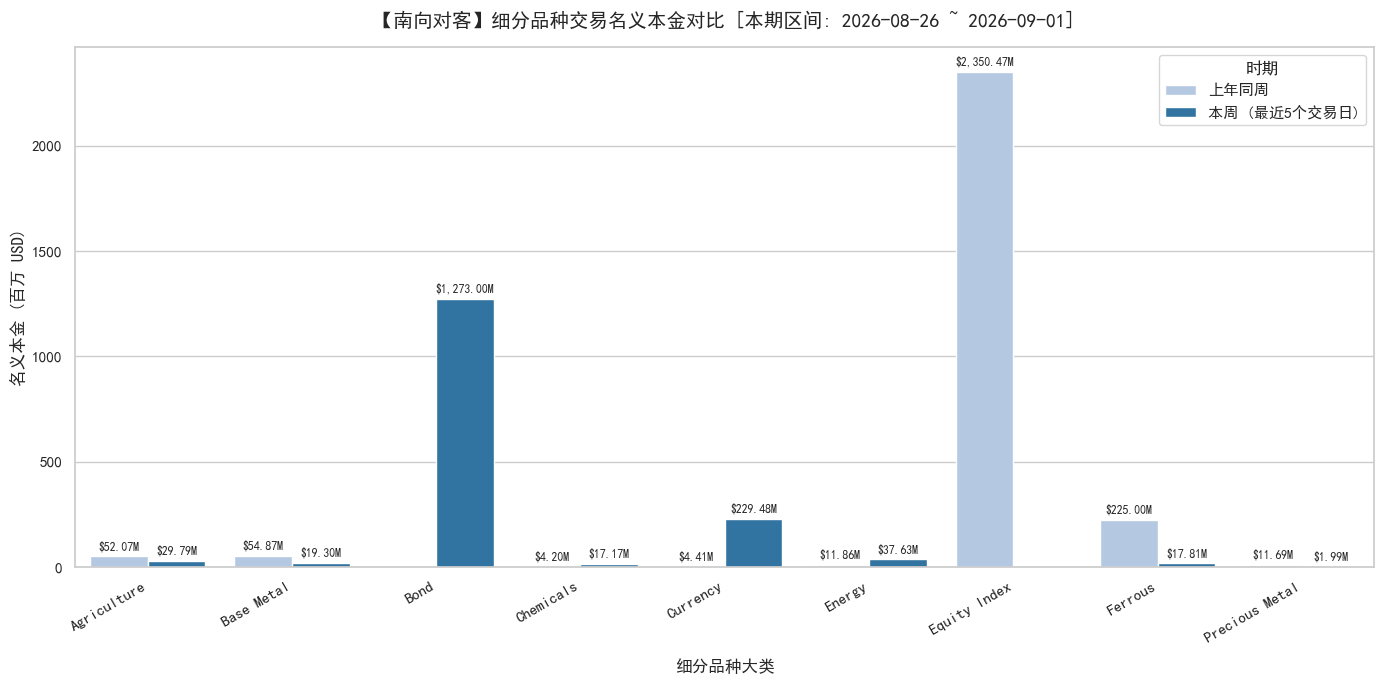

【统计一：全部 Category 加总数值与增长率】
• 上年同周 Total Notional      : 2,714.57 MM
• 本周 (最近5个交易日) Total Notional    : 1,626.17 MM
• 绝对增减额                  : -1,088.40 MM
• 增长百分比 (%)               : -40.09%


In [13]:
# 2. 调用通用周期对比函数 (此处演示周同比 mode='YoY_Week')
#    你也可以更换 mode 参数：'YoY_Year' (年同比), 'BiWeekly' (双周环比)
df_two_weeks_all, period_info = analyze_period_comparison(df, mode='YoY_Week', date_col='交易日期')

# 3. 筛选并导出南向对客与对冲的两周明细
if not df_two_weeks_all.empty:
    df_filtered = df_two_weeks_all[
        df_two_weeks_all['簿记账户'].astype(str).str.contains('南向对客|南向对冲', na=False)
    ]
    df_filtered[existing_cols + ['Period']].to_excel("本周与上年同周交易明细_南向对客与对冲.xlsx", index=False)

    # 4. 独立调用绘图函数
    summary_df = plot_client_comparison(df_two_weeks_all, period_info)
    pivot_df = calculate_growth(summary_df, period_info)


In [14]:
pivot_df.round(2)

Period,上年同周,本周 (最近5个交易日),增长绝对额,增长百分比(%)
Category,,,,
Agriculture,52.07,29.79,-22.28,-42.79
Base Metal,54.87,19.30,-35.57,-64.82
Bond,0.00,1273.00,1273.00,100.00
Chemicals,4.20,17.17,12.97,308.43
Currency,4.41,229.48,225.07,5109.34
Energy,11.86,37.63,25.76,217.20
Equity Index,2350.47,0.00,-2350.47,-100.00
Ferrous,225.00,17.81,-207.19,-92.08
Precious Metal,11.69,1.99,-9.70,-83.00
